# Project 06: GEARS sampled experiment

GEARS trained on **29,766 cells**, using up to 128 cells per original condition. The split has **88 training, 20 validation, and 20 test gene pairs**; all single-gene identities and controls are in training. Equivalent guide labels remain in the same split.

The selected checkpoint is epoch **2**, chosen from **7 completed epochs using validation error only**. GEARS beats additive on **3/20 test pairs**.

Runtime: **batch-corrected**. The corrected runtime fixes coexpression graph batching while retaining GEARS parameter names and layer structure. The vectorized loss is checked against the upstream loss and gradients. Ontology graph: local GEARS reference; Jaccard >0.1, top21 per target, deterministic ties. The learning rate halves every **5 epochs**. The pilot and revised experiment have different sampling, graph construction and schedules; their comparison cannot isolate the effect of increasing data alone.

These are exploratory results on a test set already inspected in the pilot. Configuration choices were fixed from the audit and validation protocol before this run's test scoring. This is not a fresh confirmation set or a published-paper reproduction.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

run_dir = Path('results/gears_medium')
display(pd.read_csv(run_dir / "model_comparison.csv"))


,split,model,pairs,mse_de20,mse_all_genes
0,test,additive,20,0.060234,0.001989
1,test,control,20,0.538783,0.008964
2,test,gears_medium,20,0.163833,0.006015
3,val,additive,20,0.034835,0.001378
4,val,control,20,0.521596,0.006626
5,val,gears_medium,20,0.159374,0.004590


## Comparison

MSE is calculated on each condition's saved top 20 differentially expressed genes, using measured condition means. Errors are averaged within biological pairs, then across pairs. Gene lists that depend on held-out observations are used only to score predictions. Additive predictions and graph estimation use training information.


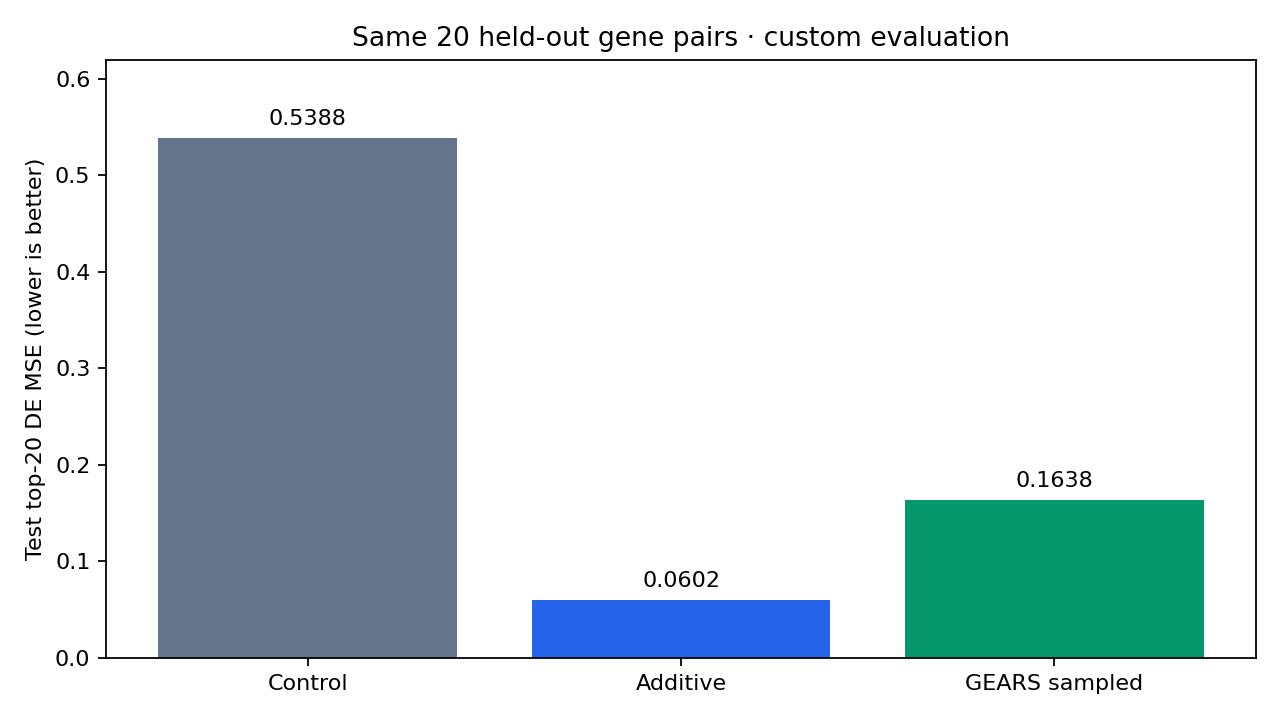

In [2]:
display(Image(filename=str(run_dir / "model_comparison.png")))


## Validation history

Test error did not choose the checkpoint.


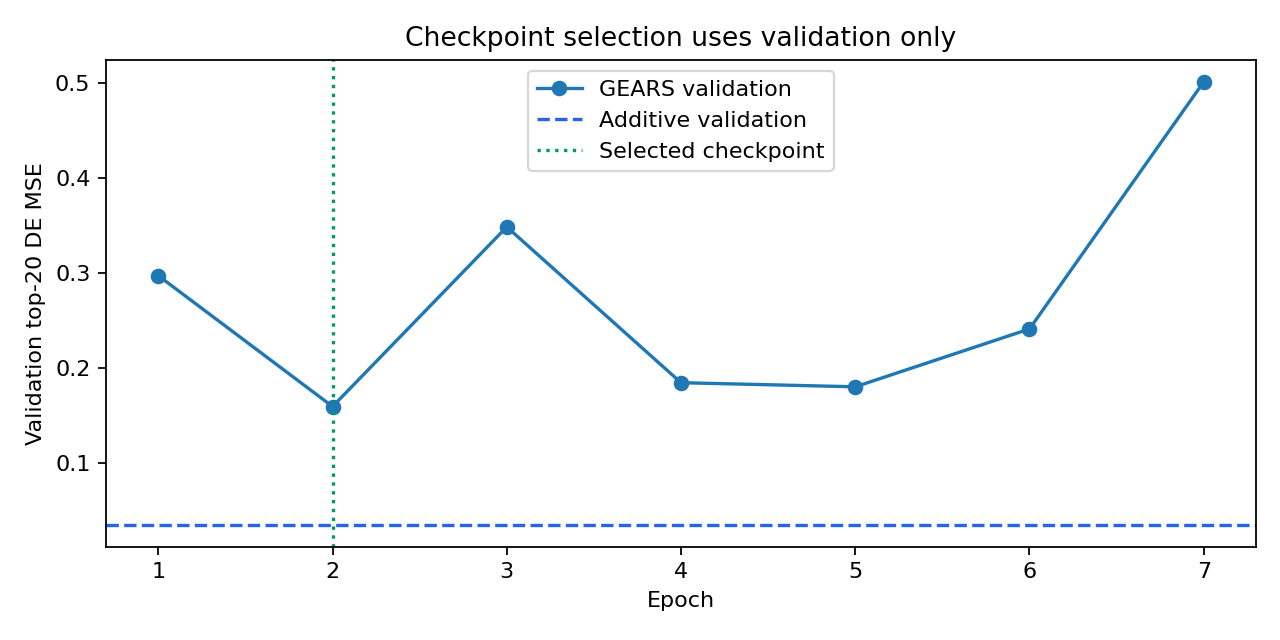

In [3]:
display(Image(filename=str(run_dir / "training_history.png")))


## Explanatory examples

These pairs have the largest relative advantages and disadvantages. They were selected after scoring for explanation, rather than tuning. If a pair has equivalent labels, its panel shows the first sorted label; table scores average all equivalent labels.


,pair,additive,gears_medium,additive_minus_gears
0,IGDCC3+PRTG,0.190489,0.054563,0.135927
1,CEBPA+CEBPB,0.100917,0.065334,0.035583
2,ETS2+MAPK1,0.102945,0.476307,-0.373362
3,SGK1+TBX2,0.029773,0.371016,-0.341242


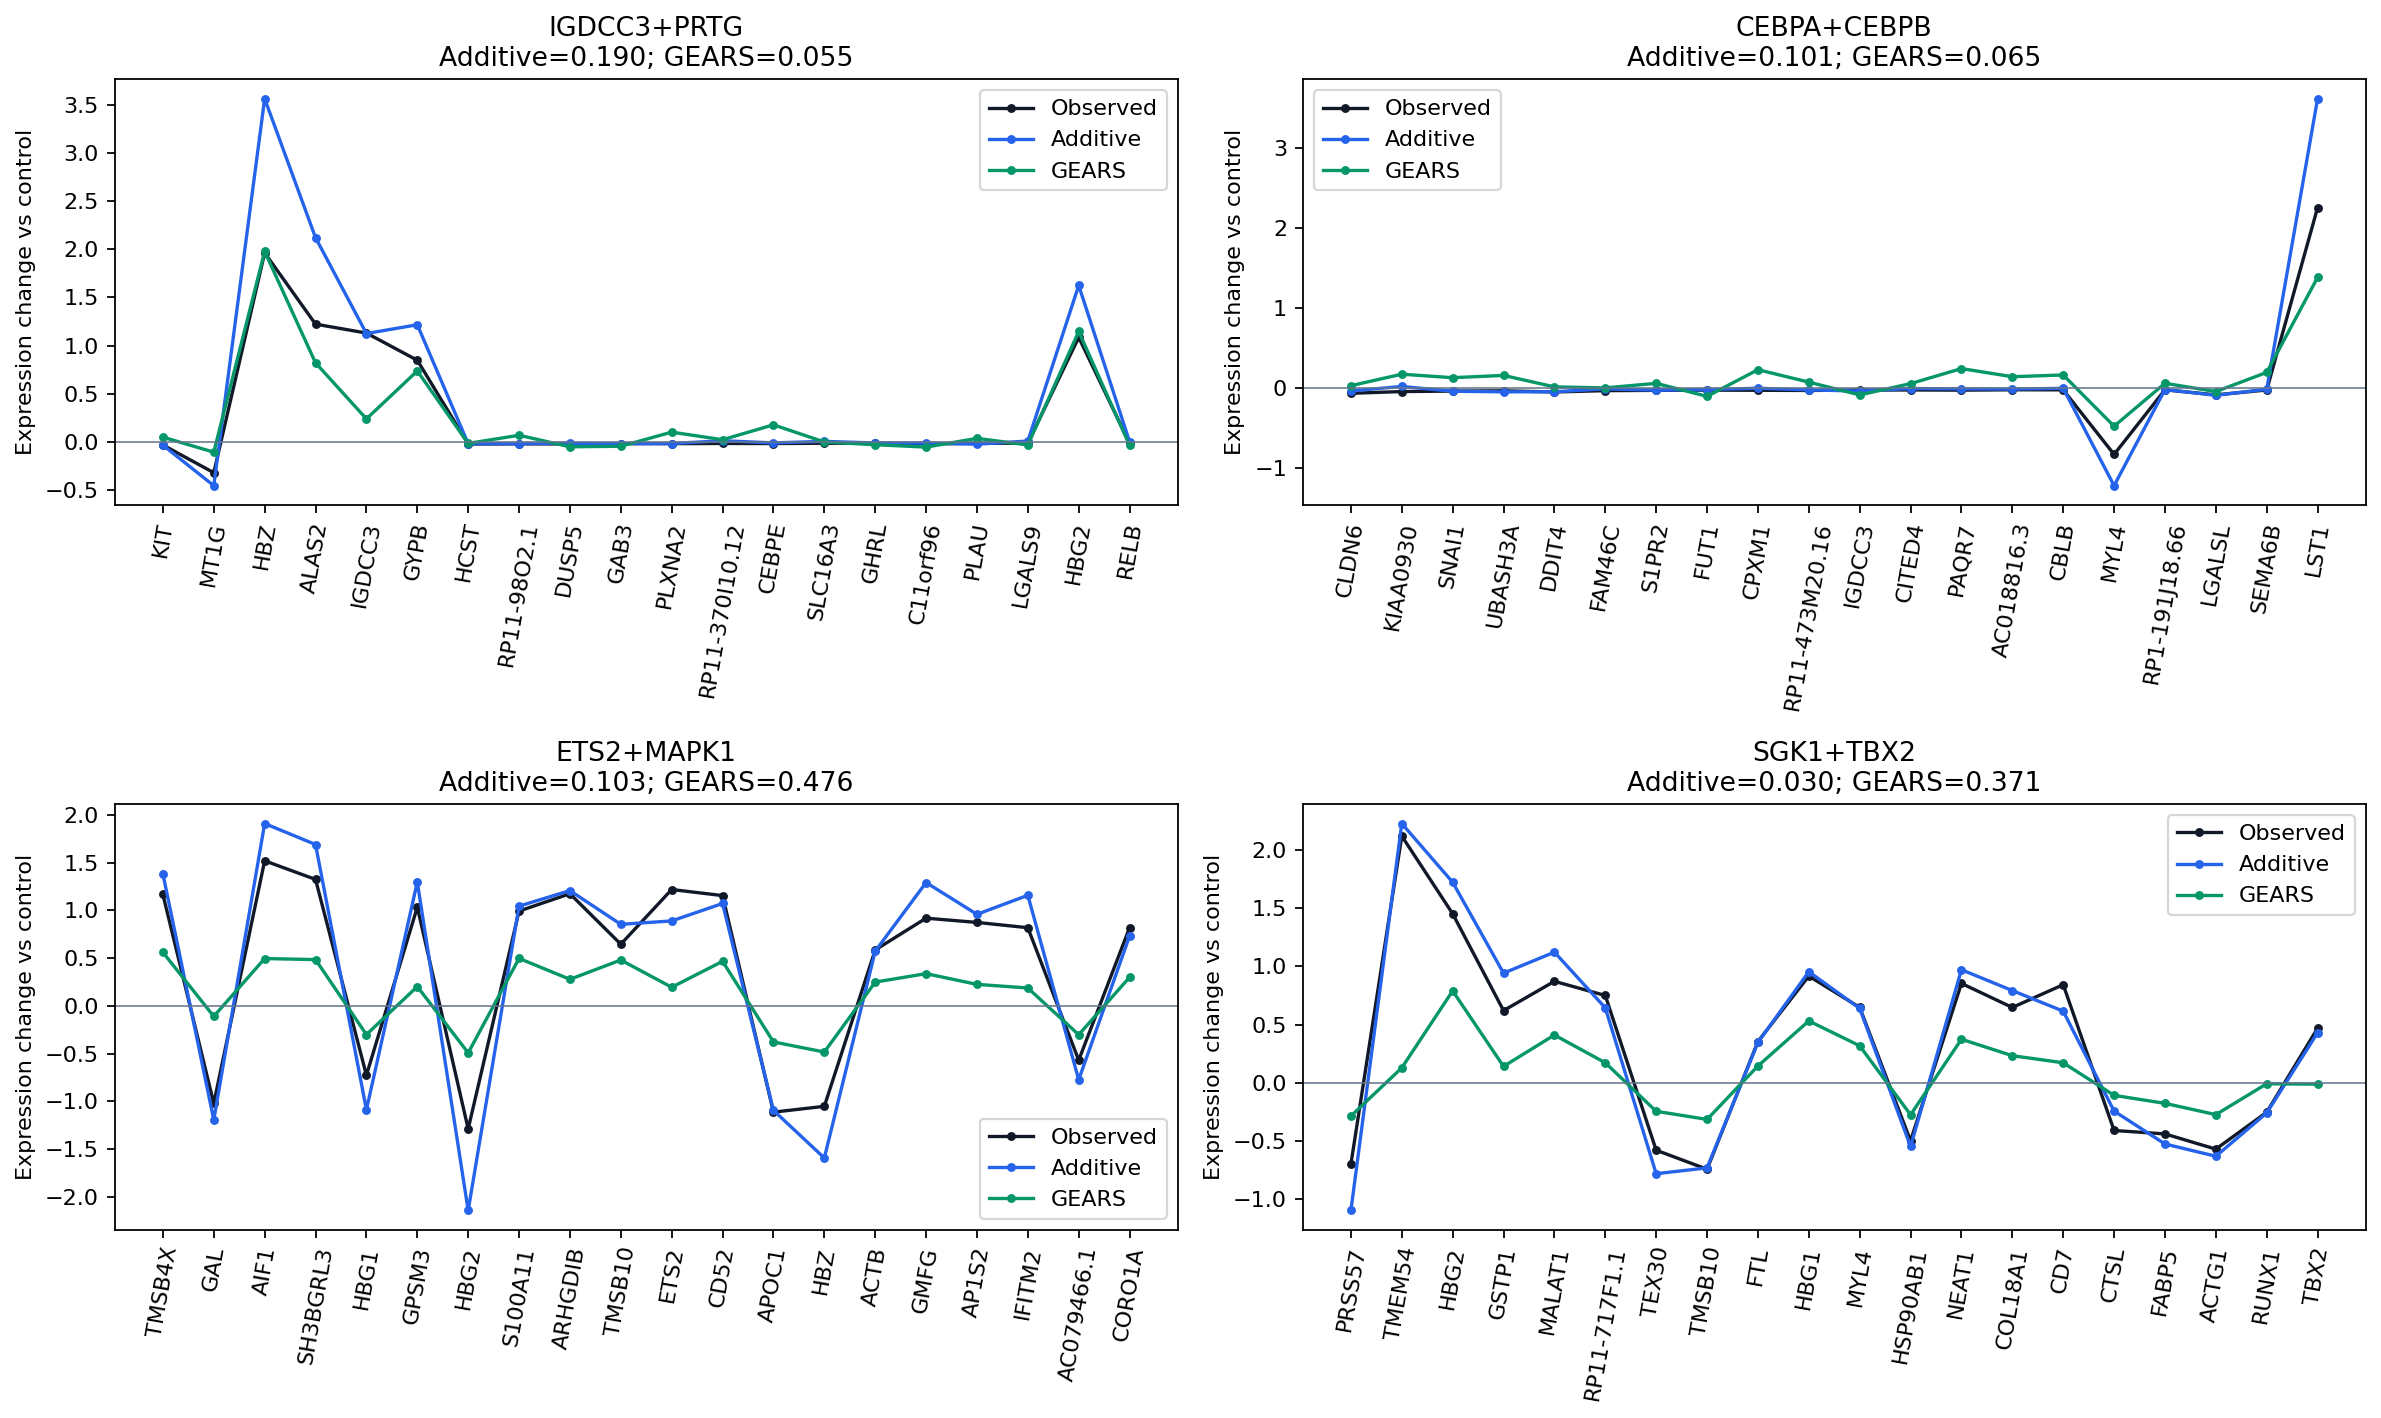

In [4]:
display(pd.read_csv(run_dir / "explanatory_examples.csv"))
display(Image(filename=str(run_dir / "test_examples.png")))


## Checkpoint verification

The selected model is saved with its graph configuration for portable CPU inference.


In [5]:
verification = run_dir / "checkpoint_verification.json"
print(verification.read_text() if verification.exists() else "Verification has not run yet.")


{
  "checkpoint_reload_passed": true,
  "checked_conditions": [
    "BCL2L11+TGFBR2",
    "BPGM+SAMD1",
    "ZC3HAV1+HOXC13"
  ],
  "saved_prediction_device": "mps",
  "reload_device": "cpu",
  "comparison": [
    {
      "condition": "BCL2L11+TGFBR2",
      "max_absolute_difference": 2.384185791015625e-06,
      "mean_absolute_difference": 4.817471577212018e-08
    },
    {
      "condition": "BPGM+SAMD1",
      "max_absolute_difference": 4.5299530029296875e-06,
      "mean_absolute_difference": 7.220062059332122e-08
    },
    {
      "condition": "ZC3HAV1+HOXC13",
      "max_absolute_difference": 5.245208740234375e-06,
      "mean_absolute_difference": 1.5771730943470175e-07
    }
  ],
  "relative_tolerance": 0.0001,
  "absolute_tolerance": 1e-05
}



## Reproduction and limits

See `README.md`, `AUDIT.md`, and the run's `experiment_plan.json` for the exact protocol. Data download and baseline preparation are handled by `prepare_project06.py`; training is handled by `train_project06.py` and `gears_runtime.py`.

Rebuild this report without retraining:

```bash
python3 report_project06.py --run-dir results/gears_medium
```

This experiment predicts expression changes after **CRISPR activation** in the processed Norman dataset. It tests unseen combinations of seen genes, on the existing normalized expression scale. It does not test new genes, another cell type, or independent biological replicates. One split and one seed do not establish broad model superiority. Pair bootstrap intervals describe variation across these held-out pairs, not biological reproducibility.
